# Task 2: Initial Stock Price Technical Analysis

## Project Context

This notebook performs initial quantitative analysis on historical stock price data. The objective is to prepare stock market datasets, compute technical indicators, and identify early price and momentum patterns that may later be connected with financial news sentiment.

The analysis supports Nova Financial Solutions’ goal of improving predictive analytics through integrated market and news intelligence.

In [1]:
import os
import sys
import warnings

project_root = os.path.abspath("..")
sys.path.append(project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

## 1. Data Loading

The historical stock price dataset contains daily trading information including open price, high price, low price, closing price, adjusted close price, and trading volume.

In [2]:
aapl_df = pd.read_csv("data/raw/AAPL.csv")

aapl_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [3]:
aapl_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   object 
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 177.0+ KB


In [4]:
aapl_df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

### Data Quality Observation

The stock price dataset was checked for missing values and data type consistency before technical indicators were computed. Proper date formatting and numeric conversion are essential for reliable quantitative analysis.

In [5]:
aapl_df["Date"] = pd.to_datetime(aapl_df["Date"])

aapl_df = aapl_df.sort_values("Date")

aapl_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


## 2. Closing Price Trend Analysis

Closing price trends provide an overview of long-term market direction and price behavior over time.

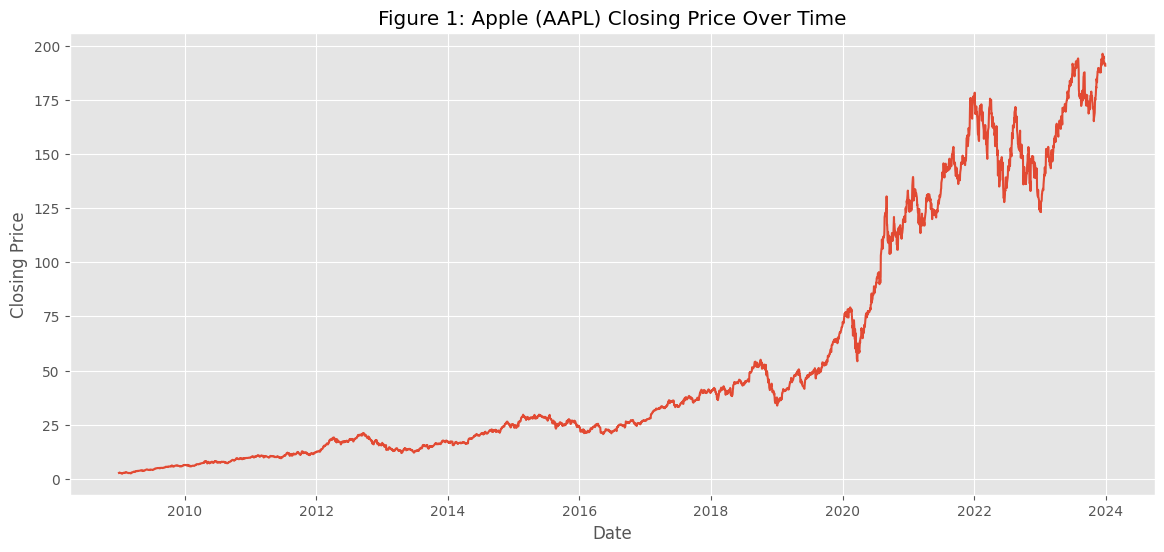

In [6]:
plt.figure(figsize=(14,6))

plt.plot(aapl_df["Date"], aapl_df["Close"])

plt.title("Figure 1: Apple (AAPL) Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

### Interpretation of Figure 1

Figure 1 shows the long-term movement of Apple’s stock price across the study period. The overall trend reflects periods of growth, correction, and recovery that may later be compared against periods of strong positive or negative news sentiment.

## 3. Simple Moving Average (SMA)

The Simple Moving Average smooths short-term fluctuations and helps identify the underlying trend direction of a stock.

In [7]:
aapl_df["SMA_20"] = aapl_df["Close"].rolling(window=20).mean()

aapl_df["SMA_50"] = aapl_df["Close"].rolling(window=50).mean()

aapl_df.head()

,Date,Close,High,Low,Open,Volume,SMA_20,SMA_50
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,NaN,NaN
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,NaN,NaN
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,NaN,NaN
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,NaN,NaN
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,NaN,NaN


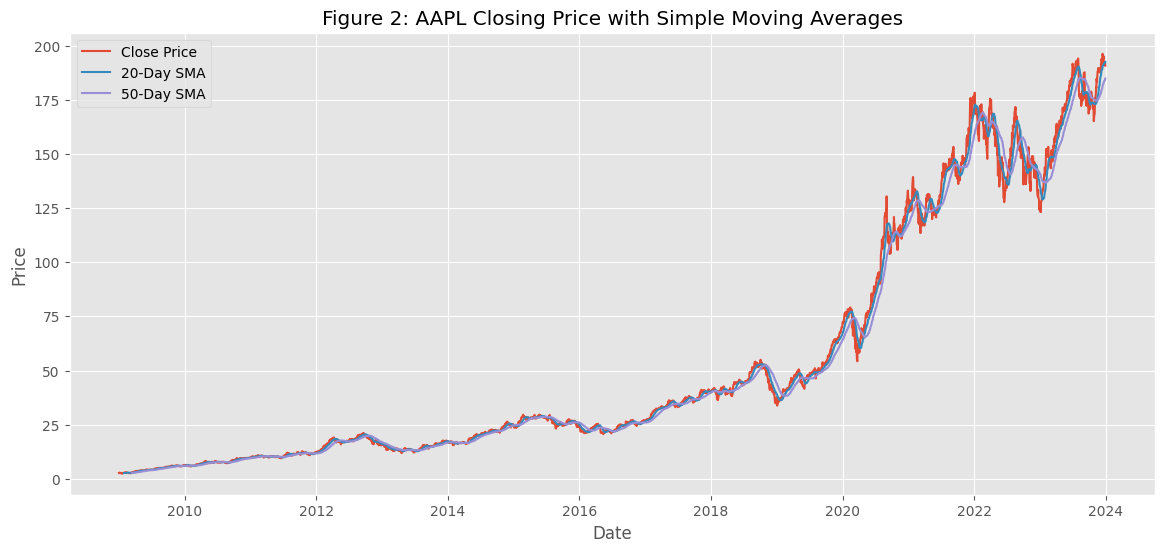

In [8]:
plt.figure(figsize=(14,6))

plt.plot(aapl_df["Date"], aapl_df["Close"], label="Close Price")

plt.plot(aapl_df["Date"], aapl_df["SMA_20"], label="20-Day SMA")

plt.plot(aapl_df["Date"], aapl_df["SMA_50"], label="50-Day SMA")

plt.title("Figure 2: AAPL Closing Price with Simple Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

### Interpretation of Figure 2

Figure 2 shows the relationship between Apple’s closing price and its short-term and medium-term moving averages. Moving averages smooth daily volatility and help identify trend direction. Crossovers between short-term and long-term averages may signal changes in market momentum.

## 4. Exponential Moving Average (EMA)

Unlike SMA, the Exponential Moving Average gives greater weight to recent prices, making it more responsive to recent market changes.

In [9]:
aapl_df["EMA_20"] = aapl_df["Close"].ewm(span=20, adjust=False).mean()

aapl_df["EMA_50"] = aapl_df["Close"].ewm(span=50, adjust=False).mean()

aapl_df.head()

,Date,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,EMA_50
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,NaN,NaN,2.721686,2.721686
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,NaN,NaN,2.732626,2.726191
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,NaN,NaN,2.738068,2.728684
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,NaN,NaN,2.737250,2.728715
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,NaN,NaN,2.741338,2.730733


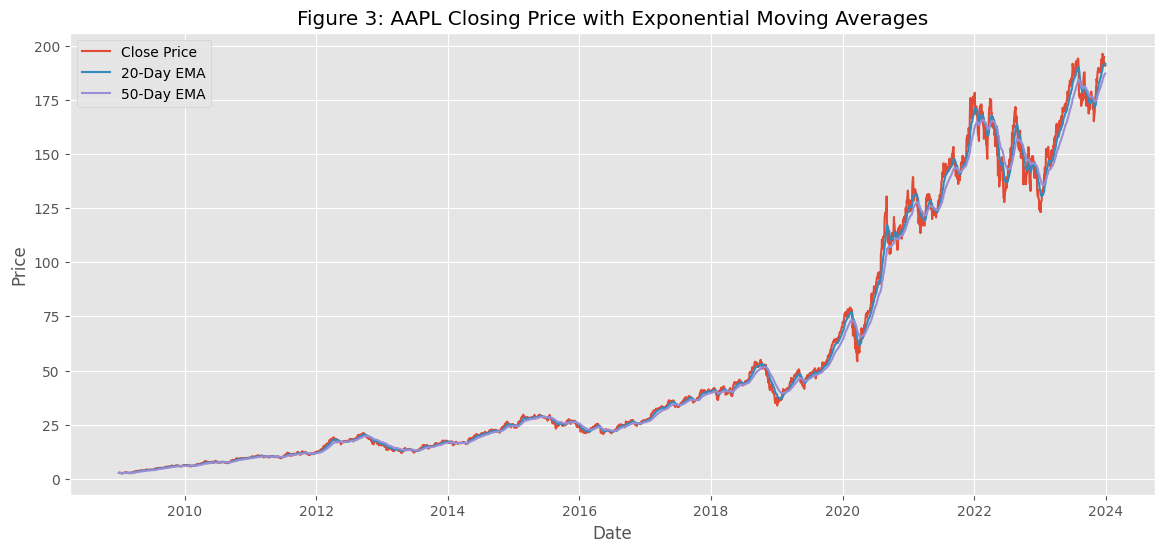

In [10]:
plt.figure(figsize=(14,6))

plt.plot(aapl_df["Date"], aapl_df["Close"], label="Close Price")

plt.plot(aapl_df["Date"], aapl_df["EMA_20"], label="20-Day EMA")

plt.plot(aapl_df["Date"], aapl_df["EMA_50"], label="50-Day EMA")

plt.title("Figure 3: AAPL Closing Price with Exponential Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

### Interpretation of Figure 3

Figure 3 shows that exponential moving averages react more quickly to recent price changes compared with simple moving averages. This makes EMA useful for detecting short-term market momentum and trend reversals.

## 5. Relative Strength Index (RSI)

The Relative Strength Index is a momentum indicator used to identify overbought and oversold conditions in the market.

In [11]:
delta = aapl_df["Close"].diff()

gain = np.where(delta > 0, delta, 0)
loss = np.where(delta < 0, -delta, 0)

gain_series = pd.Series(gain)
loss_series = pd.Series(loss)

avg_gain = gain_series.rolling(window=14).mean()
avg_loss = loss_series.rolling(window=14).mean()

rs = avg_gain / avg_loss

rsi = 100 - (100 / (1 + rs))

aapl_df["RSI_14"] = rsi

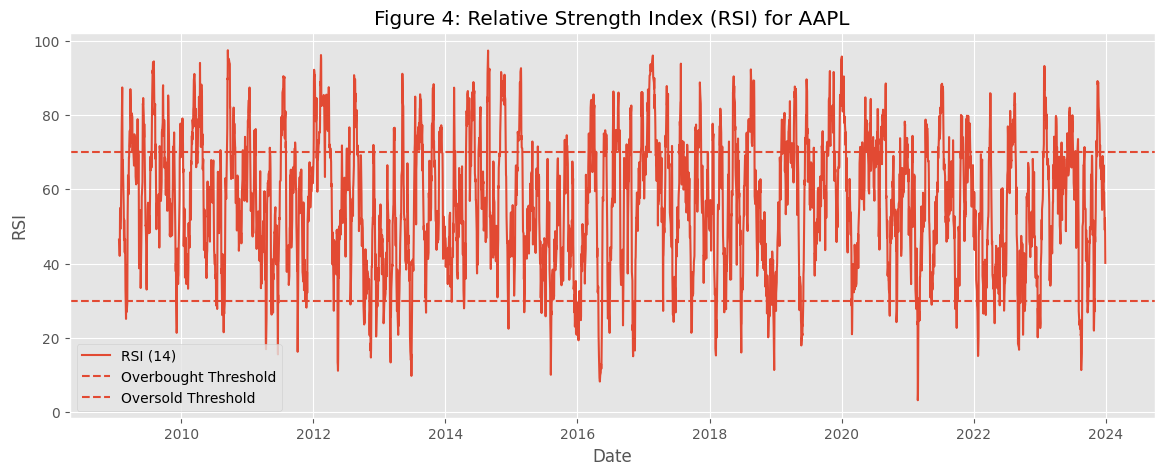

In [12]:
plt.figure(figsize=(14,5))

plt.plot(aapl_df["Date"], aapl_df["RSI_14"], label="RSI (14)")

plt.axhline(70, linestyle="--", label="Overbought Threshold")
plt.axhline(30, linestyle="--", label="Oversold Threshold")

plt.title("Figure 4: Relative Strength Index (RSI) for AAPL")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.legend()

plt.show()

### Interpretation of Figure 4

Figure 4 shows momentum fluctuations in Apple’s stock price. RSI values above 70 may indicate overbought conditions, while values below 30 may suggest oversold conditions. These momentum shifts may later be compared with changes in financial news sentiment.

## 6. Daily Return Analysis

Daily percentage returns normalize stock price movement and provide a standard metric for comparing market behavior over time.

In [13]:
# Clean column names
aapl_df.columns = aapl_df.columns.str.strip()

# Select adjusted close if available, otherwise use close
if "Adj Close" in aapl_df.columns:
    price_col = "Adj Close"
elif "Adj_Close" in aapl_df.columns:
    price_col = "Adj_Close"
elif "adj_close" in aapl_df.columns:
    price_col = "adj_close"
else:
    price_col = "Close"

aapl_df["Daily_Return"] = aapl_df[price_col].pct_change() * 100

aapl_df[["Date", price_col, "Daily_Return"]].head()

KeyError: 'Adj Close'

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(aapl_df["Date"], aapl_df["Daily_Return"])

plt.title("Figure 5: Daily Percentage Returns for AAPL")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")

plt.show()

### Interpretation of Figure 5

Figure 5 illustrates the day-to-day percentage movement in Apple’s stock price. Large spikes in returns represent periods of elevated volatility and may later correspond with major financial news events or sentiment changes.

In [ ]:
rolling_volatility = aapl_df["Daily_Return"].rolling(window=20).std()

plt.figure(figsize=(14,5))

plt.plot(aapl_df["Date"], rolling_volatility)

plt.title("Figure 6: 20-Day Rolling Volatility of AAPL Returns")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.show()

### Interpretation of Figure 6

Rolling volatility measures the variability of daily returns over time. Periods of higher volatility may indicate increased market uncertainty or stronger investor reactions to information entering the market.

# Preliminary Technical Analysis Findings

The quantitative analysis produced several important findings:

1. Apple’s stock price demonstrates clear periods of upward and downward trend movement.
2. SMA and EMA indicators reveal changes in short-term and medium-term momentum.
3. RSI analysis identifies periods approaching overbought and oversold conditions.
4. Daily return analysis highlights episodes of elevated volatility that may later be linked to financial news sentiment.
5. Technical indicators provide a quantitative foundation that will later be integrated with sentiment analysis results.

These findings establish the initial market-behavior framework required for the final correlation analysis stage.

# Relevance to the Business Objective

This technical analysis supports Nova Financial Solutions’ objective of improving predictive analytics through integrated market intelligence. Technical indicators help quantify market behavior and momentum, while later sentiment analysis will determine whether financial news tone contains predictive information about future stock movement.

# Next Steps

The next phase of the project will:

- Compute additional indicators such as MACD.
- Align financial news dates with stock trading dates.
- Apply sentiment scoring using NLP techniques such as VADER or TextBlob.
- Aggregate daily sentiment scores by stock.
- Calculate Pearson correlation between sentiment and daily returns.
- Visualize the relationship between sentiment and market movement using scatter plots and comparative analysis.

This integration phase will determine whether financial news sentiment can provide predictive insight into stock price behavior.

In [ ]:
processed_stock_path = "data/raw/AAPL_processed_interim.csv"

aapl_df.to_csv(processed_stock_path, index=False)

print(f"Processed stock dataset saved to: {processed_stock_path}")